In [16]:
import random
import numpy as np
from datetime import datetime
import pandas as pd

In [17]:
def generate_finops_event():
    """Generuje event billingowy z logiką anomalii kosztowych."""
    projects = [
        "data-warehouse-prod", "web-backend-dev", "ml-training-env", 
        "sandbox-users", "mobile-api-prod", "ci-cd-pipelines"
    ]
    
    services = [
        ("BigQuery", "Analysis", "Bytes Billed"),
        ("Compute Engine", "N2 Standard Core", "Core Hours"),
        ("Cloud Storage", "Standard Storage", "GB-Months"),
        ("Kubernetes Engine", "GKE Autopilot vCPU", "vCPU Hours"),
        ("Cloud Functions", "Tier 1 Invocations", "Invocations")
    ]
    
    project_id = random.choice(projects)
    service_name, sku_category, usage_unit = random.choice(services)
    
    cost_usd = round(np.random.exponential(scale=5.0) + 0.1, 4)
    if random.random() > 0.95:
        cost_usd = round(random.uniform(301.0, 500.0), 2)

    usage_amount = round(cost_usd * random.uniform(1.5, 3.0), 2)
    
    is_weekend = np.random.choice([0, 1], p=[5/7, 2/7])
    
   
    is_anomaly = 0
    
    # R1: Drogie zapytania BQ
    if service_name == "BigQuery" and random.random() > 0.8:
        cost_usd = round(random.uniform(200.0, 800.0), 2)
        usage_amount = round(cost_usd * 150, 2)
        is_anomaly = 3
        
    # R2: Włączone maszyny w środowiskach dev/sandbox na weekend
    elif is_weekend == 1 and ("dev" in project_id or "sandbox" in project_id):
        if service_name in ["Compute Engine", "Kubernetes Engine"] and cost_usd > 15.0:
            is_anomaly = 2
            cost_usd = round(cost_usd * random.uniform(3.0, 6.0), 2)
            
    # R3: Skrajny rachunek
    elif cost_usd > 300.0:
        is_anomaly = 1

    payload = {
        "billing_record_id": str(random.randint(100000000, 999999999)),
        "project_id": project_id,
        "service": service_name,
        "sku": sku_category,
        "usage_unit": usage_unit,
        "usage_amount": usage_amount,
        "cost_usd": cost_usd,
        # "timestamp": current_time.isoformat(),
        "is_weekend": is_weekend,
        "is_anomaly": is_anomaly
    }
    return payload

In [18]:
generate_finops_event()

{'billing_record_id': '649637395',
 'project_id': 'data-warehouse-prod',
 'service': 'Cloud Storage',
 'sku': 'Standard Storage',
 'usage_unit': 'GB-Months',
 'usage_amount': 6.65,
 'cost_usd': 2.942,
 'is_weekend': np.int64(0),
 'is_anomaly': 0}

In [19]:
event_list = []
for _ in range(10000):
    event = generate_finops_event()
    event_list.append(event)

In [20]:
df = pd.DataFrame(event_list)
df.head()

,billing_record_id,project_id,service,sku,usage_unit,usage_amount,cost_usd,is_weekend,is_anomaly
0,444252517,ml-training-env,Compute Engine,N2 Standard Core,Core Hours,3.14,1.6671,0,0
1,634328748,ml-training-env,Kubernetes Engine,GKE Autopilot vCPU,vCPU Hours,30.99,20.3642,0,0
2,766898251,ci-cd-pipelines,Compute Engine,N2 Standard Core,Core Hours,13.50,5.0399,0,0
3,287808581,sandbox-users,Cloud Storage,Standard Storage,GB-Months,0.18,0.1190,1,0
4,177179969,data-warehouse-prod,Cloud Functions,Tier 1 Invocations,Invocations,0.21,0.1409,1,0


In [21]:
df['is_anomaly'].value_counts()

is_anomaly
0    9111
1     451
3     402
2      36
Name: count, dtype: int64

In [22]:
len(df[df['is_anomaly'] >= 1])/len(df) * 100

8.89

In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_model = df.copy()


cat_cols = ['project_id', 'service', 'sku', 'usage_unit']
le = LabelEncoder()
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])


feature_cols = ['usage_amount', 'cost_usd', 'is_weekend'] + [c + '_enc' for c in cat_cols]
X = df_model[feature_cols]


y_true = (df['is_anomaly'] >= 1).astype(int)

print(f"Rekordów: {len(X)}")
print(f"Anomalie (ground truth): {y_true.sum()} ({y_true.mean()*100:.1f}%)")
print(f"Cechy: {feature_cols}")

Rekordów: 10000
Anomalie (ground truth): 889 (8.9%)
Cechy: ['usage_amount', 'cost_usd', 'is_weekend', 'project_id_enc', 'service_enc', 'sku_enc', 'usage_unit_enc']


In [24]:
contamination = round(float(y_true.mean()), 3)

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination,
    random_state=42
)
iso_forest.fit(X)

raw_pred = iso_forest.predict(X)
y_pred = (raw_pred == -1).astype(int)

print(f"Parametr contamination: {contamination}")
print(f"Isolation Forest – przewidziane anomalie: {y_pred.sum()} ({y_pred.mean()*100:.1f}%)")

Parametr contamination: 0.089
Isolation Forest – przewidziane anomalie: 890 (8.9%)


In [25]:
import joblib
import os

model_path = "isolation_forest_model.pkl"
joblib.dump(iso_forest, model_path)

loaded_model = joblib.load(model_path)
test_pred = loaded_model.predict(X.iloc[[0]])

In [26]:
import joblib


model_data = {
    "model": iso_forest,
    "label_encoders": {col: le for col in cat_cols}
}

joblib.dump(model_data, "finops_model.joblib")
print("Model i enkodery zapisane poprawnie.")

Model i enkodery zapisane poprawnie.


=== Raport klasyfikacji ===
              precision    recall  f1-score   support

    Normalny       1.00      1.00      1.00      9111
    Anomalia       0.96      0.97      0.96       889

    accuracy                           0.99     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.99      0.99      0.99     10000



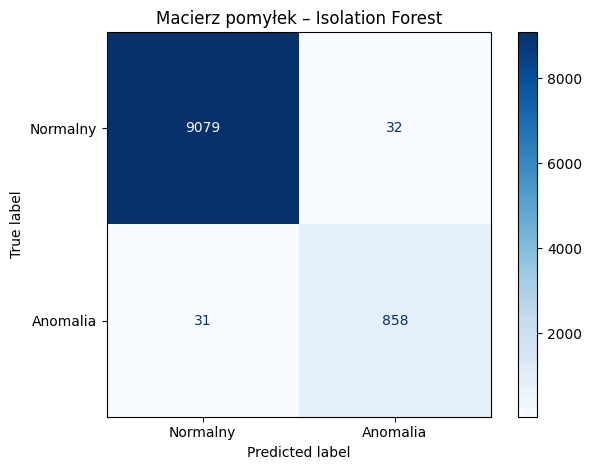

In [27]:
print("=== Raport klasyfikacji ===")
print(classification_report(y_true, y_pred, target_names=['Normalny', 'Anomalia']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normalny', 'Anomalia'])
disp.plot(cmap='Blues')
plt.title('Macierz pomyłek – Isolation Forest')
plt.tight_layout()
plt.show()

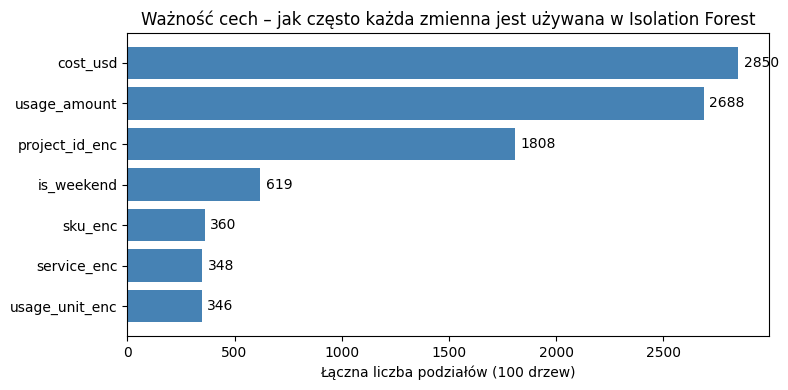


Udział procentowy każdej cechy w podziałach:
         Cecha  Liczba podziałów    %
      cost_usd            2850.0 31.6
  usage_amount            2688.0 29.8
project_id_enc            1808.0 20.0
    is_weekend             619.0  6.9
       sku_enc             360.0  4.0
   service_enc             348.0  3.9
usage_unit_enc             346.0  3.8


In [28]:
import numpy as np


feature_counts = np.zeros(len(feature_cols))
for estimator in iso_forest.estimators_:
    tree_ = estimator.tree_
    splits = tree_.feature[tree_.feature >= 0]
    for f_idx in splits:
        feature_counts[f_idx] += 1

feat_imp = pd.DataFrame({'Cecha': feature_cols, 'Liczba podziałów': feature_counts})
feat_imp = feat_imp.sort_values('Liczba podziałów', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(feat_imp['Cecha'], feat_imp['Liczba podziałów'], color='steelblue')
plt.bar_label(bars, fmt='%.0f', padding=4)
plt.xlabel('Łączna liczba podziałów (100 drzew)')
plt.title('Ważność cech – jak często każda zmienna jest używana w Isolation Forest')
plt.tight_layout()
plt.show()

print("\nUdział procentowy każdej cechy w podziałach:")
feat_imp_pct = feat_imp.copy()
feat_imp_pct['%'] = (feat_imp_pct['Liczba podziałów'] / feat_imp_pct['Liczba podziałów'].sum() * 100).round(1)
print(feat_imp_pct.sort_values('%', ascending=False).to_string(index=False))

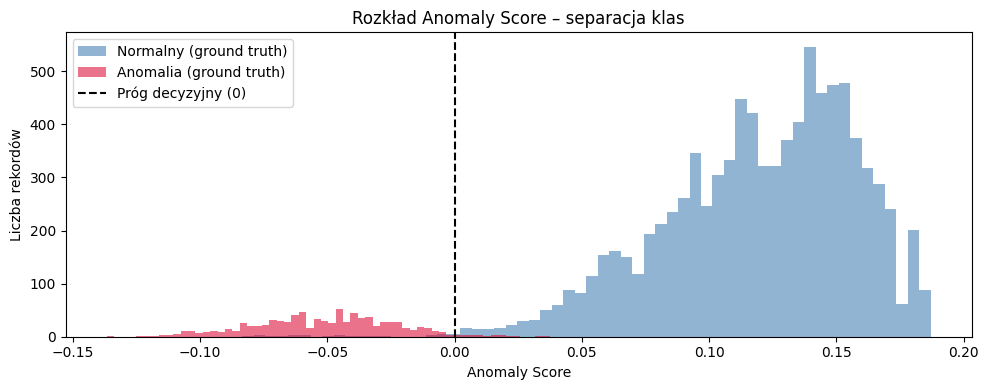

Średni score normalnych:  0.1196
Średni score anomalii:    -0.0507


In [29]:
scores = iso_forest.decision_function(X)

plt.figure(figsize=(10, 4))
plt.hist(scores[y_true == 0], bins=60, alpha=0.6, color='steelblue', label='Normalny (ground truth)')
plt.hist(scores[y_true == 1], bins=60, alpha=0.6, color='crimson',   label='Anomalia (ground truth)')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Próg decyzyjny (0)')
plt.xlabel('Anomaly Score')
plt.ylabel('Liczba rekordów')
plt.title('Rozkład Anomaly Score – separacja klas')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Średni score normalnych:  {scores[y_true==0].mean():.4f}")
print(f"Średni score anomalii:    {scores[y_true==1].mean():.4f}")